# <center>Maximum likelihood estimation</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Define the likelihood, log-likelihood, score, and Fisher information of a parametric model, and derive their basic algebraic properties.

* State and prove the consistency and asymptotic normality of the MLE under standard regularity conditions, recognizing them as instances of the LLN/CLT/CMT toolkit from Lectures 1–2.

* State and verify numerically the *information identity* $-\mathbb{E}[H(\theta_0)] = \mathbb{E}[s(\theta_0)s(\theta_0)^\top] = \mathcal{I}(\theta_0)$, which holds at the truth under correct specification and is the foundation of the Cramér–Rao efficiency bound.

* Implement maximum likelihood from scratch for a logit model, log-likelihood, analytical score and Hessian, Newton–Raphson and BFGS optimization, and apply it to the Mroz (1987) labor-force-participation problem.

* Compute the three classical test statistics, likelihood ratio (LR), Wald, and Lagrange multiplier (LM / score), and verify their asymptotic equivalence under the null.

* Compute the sandwich (robust) variance estimator $H^{-1} J H^{-1}$, recognize it as the appropriate covariance under model misspecification, and connect to the asymptotic-variance results of Lecture 4.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapters 10, 22.

**[vdV]** van der Vaart, A. W. (1998). *Asymptotic Statistics*. Cambridge University Press. Chapter 5.

**[Wh]** White, H. (1982). 'Maximum Likelihood Estimation of Misspecified Models'. *Econometrica*, 50(1), 1–25.

**[CT]** Cameron, A. C., and Trivedi, P. K. (2005). *Microeconometrics: Methods and Applications*. Cambridge University Press.

**[M]** Mroz, T. A. (1987). 'The Sensitivity of an Empirical Model of Married Women's Hours of Work to Economic and Statistical Assumptions'. *Econometrica*, 55(4), 765–799.

# Motivation: from moments to densities

* Lectures 3–7 worked exclusively with linear regression and its variants. The estimators were defined by orthogonality conditions ($\mathbb{E}[x\varepsilon] = 0$) and the asymptotic theory followed from sample-mean identities.

* Many problems in econometrics, discrete choice, count data, duration models, censored regressions, do not admit a linear representation, and the moment conditions that pin them down arise naturally from a fully specified parametric likelihood. The maximum likelihood estimator is the canonical estimator in such settings: it has the smallest asymptotic variance achievable by any consistent estimator under the model (Cramér–Rao), and it generates the three classical hypothesis tests (LR, Wald, LM) that share asymptotic equivalence under the null.

* This lecture develops the theory and applies it to the canonical binary-choice model on the Mroz (1987) labor force participation data: $y_i = 1$ if woman $i$ works, $y_i = 0$ otherwise. We model the probability via a logit and show that every step, score, Hessian, asymptotic variance, hypothesis tests, has a clean numerical implementation that matches `statsmodels.Logit` to machine precision.

## Loading our libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from types import SimpleNamespace
import statsmodels.api as sm

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
print(f'Total observations:        {len(mroz)}')
print(f'In labor force (lfp = 1):  {(mroz["lfp"] == 1).sum()}')
print(f'Out of labor force:         {(mroz["lfp"] == 0).sum()}')

# Outcome and design matrix for the LFP regression
y_i = mroz['lfp'].astype(float).values
X_i_k = np.column_stack([
    np.ones(len(mroz)),
    mroz['age'].values,
    mroz['educ'].values,
    mroz['exper'].values,
    mroz['exper'].values ** 2,
    mroz['kids5'].values,            # children under 6
    mroz['kids618'].values,          # children 6–18
    mroz['nwifeinc'].values,         # household non-wife income
])
xnames = ['const', 'age', 'educ', 'exper', 'exper^2', 'kids5', 'kids618', 'nwifeinc']
I, K = X_i_k.shape
print(f'\nI = {I}, K = {K}')


Total observations:        753
In labor force (lfp = 1):  428
Out of labor force:         325

I = 753, K = 8


# 1. Likelihood, log-likelihood, score, and Fisher information

## 1.1 Definitions

Let $\{f(\cdot\,;\theta)\,:\,\theta\in\Theta\subseteq\mathbb{R}^K\}$ be a parametric family of densities, and let $\{Z_i\}_{i=1}^I$ be i.i.d. with density $f(\cdot\,;\theta_0)$ for some unknown true value $\theta_0\in\Theta$. The (log-)likelihood of the sample is
$$
\ell_I(\theta) := \sum_{i=1}^I \log f(Z_i;\theta).
$$
The **score** of an individual observation and the **Fisher information matrix** are
$$
s_i(\theta) := \nabla_\theta \log f(Z_i;\theta), \qquad \mathcal{I}(\theta) := \mathbb{E}\bigl[s_i(\theta)\,s_i(\theta)^\top\bigr].
$$

## 1.2 Three identities

For sufficiently smooth densities, integration by parts under standard regularity yields:

$$
\textbf{(i)}\quad \mathbb{E}_\theta\bigl[s_i(\theta)\bigr] = 0 \qquad \text{for all }\theta\in\Theta.
$$

$$
\textbf{(ii)}\quad \mathcal{I}(\theta) = -\mathbb{E}_\theta\bigl[\nabla_\theta s_i(\theta)\bigr] = -\mathbb{E}_\theta\bigl[\nabla^2_\theta\log f(Z_i;\theta)\bigr]
$$
(the **information identity**: minus the expected Hessian equals the expected outer product of scores).

$$
\textbf{(iii)}\quad \theta_0 \;\text{maximizes}\; Q_0(\theta) := \mathbb{E}_{\theta_0}\bigl[\log f(Z_i;\theta)\bigr].
$$

The third identity, the *Kullback–Leibler property*, says that the population log-likelihood is uniquely maximized at the truth. The MLE will therefore consistently estimate $\theta_0$ provided we can interchange the maximization with the limit $I\to\infty$, which is the analytic content of consistency.

# 2. The MLE: definition and asymptotic theory

The maximum likelihood estimator is
$$
\hat\theta_I := \arg\max_{\theta\in\Theta} \frac{1}{I}\ell_I(\theta).
$$

## 2.1 Consistency

---

**Theorem (Consistency of MLE).** Under standard regularity conditions, including $\Theta$ compact, $\theta_0$ identified by (iii), and uniform convergence $\sup_\theta\lvert I^{-1}\ell_I(\theta) - Q_0(\theta)\rvert\xrightarrow{p}0$, $\hat\theta_I\xrightarrow{p}\theta_0$.

---

**Proof sketch.** $\hat\theta_I$ maximizes a function that converges uniformly to $Q_0$, which is uniquely maximized at $\theta_0$. By the argmax continuous-mapping theorem, $\hat\theta_I\xrightarrow{p}\theta_0$. $\square$

## 2.2 Asymptotic normality

---

**Theorem (Asymptotic normality of MLE).** Under additional regularity (smoothness of $f$, finite $\mathcal{I}(\theta_0)$, dominated convergence to allow differentiation under the integral),
$$
\sqrt{I}\,(\hat\theta_I - \theta_0)\;\xrightarrow{d}\;\mathcal{N}\bigl(0,\,\mathcal{I}(\theta_0)^{-1}\bigr).
$$

---

**Proof.** A first-order Taylor expansion of the score around $\theta_0$, evaluated at $\hat\theta_I$, gives
$$
0 = \frac{1}{\sqrt I}\sum_i s_i(\hat\theta_I) = \frac{1}{\sqrt I}\sum_i s_i(\theta_0) + \biggl(\frac{1}{I}\sum_i\nabla_\theta s_i(\tilde\theta_I)\biggr)\sqrt{I}(\hat\theta_I - \theta_0).
$$
By the LLN applied to the Hessian, $I^{-1}\sum_i\nabla_\theta s_i(\tilde\theta_I)\xrightarrow{p}\mathbb{E}[\nabla_\theta s_i(\theta_0)] = -\mathcal{I}(\theta_0)$. By the CLT applied to the score, $I^{-1/2}\sum_i s_i(\theta_0)\xrightarrow{d}\mathcal{N}(0,\mathcal{I}(\theta_0))$. Slutsky's theorem completes the argument. $\square$

The variance $\mathcal{I}(\theta_0)^{-1}$ is the **Cramér–Rao bound**: no other consistent estimator can do strictly better asymptotically under the model. The MLE is *first-order efficient*.

## 2.3 Sample analogs of the Fisher information

There are three asymptotically equivalent sample analogs of $\mathcal{I}(\theta_0)$:

* **Outer product of gradients (OPG):** $\;\widehat{\mathcal{J}}_I := I^{-1}\sum_i s_i(\hat\theta_I)\,s_i(\hat\theta_I)^\top$.
* **Negative Hessian:** $\;\widehat H_I := -I^{-1}\sum_i\nabla_\theta s_i(\hat\theta_I)$.
* **Expected information:** $\widehat{\mathcal{I}}_I := -I^{-1}\sum_i\mathbb{E}\bigl[\nabla_\theta s_i(\theta)\bigr]\big|_{\theta=\hat\theta_I}$, when the expectation is available in closed form.

Under correct specification, all three converge in probability to the same limit $\mathcal{I}(\theta_0)$ (the information identity). Under *misspecification*, when the data are not generated by $f(\cdot\,;\theta_0)$ for any $\theta_0$, the OPG and the negative Hessian converge to different limits, and the **sandwich** variance
$$
V_{\text{sand}} := H^{-1}\,J\,H^{-1}
$$
is the appropriate large-sample covariance for $\hat\theta_I$, generalizing the Eicker–White variance from Lecture 4.

# 3. The logit model

## 3.1 Specification

Let $y_i\in\{0,1\}$ and $x_i\in\mathbb{R}^K$. The logit model assumes
$$
P(y_i = 1\mid x_i) = \Lambda(x_i^\top\beta), \qquad \Lambda(z) := \frac{1}{1+e^{-z}}.
$$
The log-likelihood contribution of observation $i$ is
$$
\ell_i(\beta) = y_i\log\Lambda(x_i^\top\beta) + (1-y_i)\log(1-\Lambda(x_i^\top\beta)).
$$
Since $\log\Lambda(z) = z - \log(1+e^z)$ and $\log(1-\Lambda(z)) = -\log(1+e^z)$, this simplifies to
$$
\ell_i(\beta) = y_i\,x_i^\top\beta - \log(1+e^{x_i^\top\beta}).
$$

## 3.2 Score and Hessian

A direct calculation gives
$$
s_i(\beta) = \bigl(y_i - \Lambda(x_i^\top\beta)\bigr)x_i, \qquad
\nabla_\beta s_i(\beta) = -\Lambda(x_i^\top\beta)\bigl(1-\Lambda(x_i^\top\beta)\bigr)\,x_i x_i^\top.
$$
The Hessian is *negative-definite* everywhere (assuming $X$ has full column rank), so the log-likelihood is globally concave and the MLE is the unique solution to the score equation $\sum_i s_i(\hat\beta) = 0$.

The expected information has a closed form:
$$
\mathcal{I}(\beta) = \mathbb{E}\bigl[\Lambda(x^\top\beta)(1-\Lambda(x^\top\beta))\,x x^\top\bigr],
$$
and equals minus the expected Hessian: the information identity, in this model, reduces to the textbook GLM weighting by $\Lambda(1-\Lambda)$.

In [3]:
from scipy.special import expit as Λ          # numerically stable logistic

def loglik(β_k, X_i_k, y_i):
    z_i = X_i_k @ β_k
    # log(1 + e^z) computed stably as max(z,0) + log1p(e^{-|z|})
    log1p_exp_i = np.maximum(z_i, 0) + np.log1p(np.exp(-np.abs(z_i)))
    return np.sum(y_i * z_i - log1p_exp_i)

def score(β_k, X_i_k, y_i):
    return X_i_k.T @ (y_i - Λ(X_i_k @ β_k))

def hessian(β_k, X_i_k, y_i):
    p_i = Λ(X_i_k @ β_k)
    w_i = p_i * (1.0 - p_i)
    return -(X_i_k * w_i[:, None]).T @ X_i_k


# 4. Maximizing the log-likelihood

We compute the MLE two ways:

* **Newton–Raphson** with the analytical Hessian: from $\beta^{(t+1)} = \beta^{(t)} - H(\beta^{(t)})^{-1}s(\beta^{(t)})$, exploiting the closed-form negative-definite Hessian.

* **BFGS** via `scipy.optimize.minimize`, supplying the analytical gradient. BFGS builds an approximation of the inverse Hessian as it iterates and converges in fewer evaluations than gradient-only methods.

Both should converge to the same global optimum, since the log-likelihood is strictly concave.

In [4]:
def newton_raphson(X_i_k, y_i, β0_k=None, tol=1e-8, max_iter=50):
    """Newton–Raphson for the logit MLE.

    Returns an explicit convergence flag rather than leaving the caller to assume success.
    Two details matter and are easy to get wrong:

    * the stopping test is applied to the score at the **final** iterate, not at the iterate
      before the last update;
    * a Newton step is only accepted if it does not lower the log-likelihood, which guards
      against a step taken on a badly conditioned Hessian.
    """
    if β0_k is None:
        β0_k = np.zeros(X_i_k.shape[1])
    β_k = β0_k.copy()
    history = [loglik(β_k, X_i_k, y_i)]
    converged, it = False, 0
    for it in range(1, max_iter + 1):
        s_k = score(β_k, X_i_k, y_i)
        H_k_k = hessian(β_k, X_i_k, y_i)
        Δ_k = np.linalg.solve(H_k_k, s_k)
        β_try = β_k - Δ_k
        ll_try = loglik(β_try, X_i_k, y_i)
        if ll_try < history[-1] - 1e-8:
            raise RuntimeError(f'Newton step decreased the log-likelihood at iteration {it}')
        β_k = β_try
        history.append(ll_try)
        if np.max(np.abs(score(β_k, X_i_k, y_i))) < tol:      # score at the FINAL iterate
            converged = True
            break
    return SimpleNamespace(β_k=β_k, history=history, iters=it, converged=converged,
                           max_score=float(np.max(np.abs(score(β_k, X_i_k, y_i)))))

nr = newton_raphson(X_i_k, y_i)
βnr_k, hist_nr, iters_nr = nr.β_k, nr.history, nr.iters
print(f'Newton–Raphson: converged = {nr.converged} in {nr.iters} iterations')
print(f'   max |score| at the solution = {nr.max_score:.3e}')
print(f'   log-likelihood              = {loglik(βnr_k, X_i_k, y_i):.6f}')

# BFGS via scipy: minimize the negative log-likelihood
res_bfgs = optimize.minimize(
    fun=lambda β_k: -loglik(β_k, X_i_k, y_i),
    x0=np.zeros(K),
    jac=lambda β_k: -score(β_k, X_i_k, y_i),
    method='BFGS',
    options={'gtol': 1e-8},
)
βbfgs_k = res_bfgs.x
score_bfgs = np.max(np.abs(score(βbfgs_k, X_i_k, y_i)))

# Report what SciPy actually says, not what we hope it says.
print(f'\nBFGS: success = {res_bfgs.success}  (status {res_bfgs.status})')
print(f'   message                     = {res_bfgs.message}')
print(f'   iterations                  = {res_bfgs.nit}')
print(f'   max |score| at the solution = {score_bfgs:.3e}')
print(f'   log-likelihood              = {-res_bfgs.fun:.6f}')

print(f'\nmax |β̂_NR - β̂_BFGS| = {np.max(np.abs(βnr_k - βbfgs_k)):.2e}')

# The verification that actually matters: the two routines must agree, and the Newton
# solution must solve the score equations. Fail loudly if either breaks.
assert nr.converged, 'Newton–Raphson did not meet its score tolerance'
assert nr.max_score < 1e-8, f'Newton score too large: {nr.max_score:.2e}'
assert np.max(np.abs(βnr_k - βbfgs_k)) < 1e-6, 'the two optimizers disagree'
print('\nVerification passed: both routines locate the same maximum.')


Newton–Raphson: converged = True in 5 iterations
   max |score| at the solution = 1.287e-09
   log-likelihood              = -401.765151

BFGS: success = False  (status 2)
   message                     = Desired error not necessarily achieved due to precision loss.
   iterations                  = 21
   max |score| at the solution = 1.404e-06
   log-likelihood              = -401.765151

max |β̂_NR - β̂_BFGS| = 8.46e-10

Verification passed: both routines locate the same maximum.


## 4.1 Estimates and comparison with `statsmodels.Logit`

In [5]:
# Variance estimators
Hhat_k_k   = hessian(βnr_k, X_i_k, y_i)
Jhat_k_k   = (X_i_k * (y_i - Λ(X_i_k @ βnr_k))[:, None]).T @ (X_i_k * (y_i - Λ(X_i_k @ βnr_k))[:, None])
Vclass_k_k = np.linalg.inv(-Hhat_k_k)               # = (-H)^{-1}; correct under the model
Vsand_k_k  = Vclass_k_k @ Jhat_k_k @ Vclass_k_k           # robust under misspecification
seclass_k = np.sqrt(np.diag(Vclass_k_k))
sesand_k  = np.sqrt(np.diag(Vsand_k_k))

# statsmodels comparison
sm_logit = sm.Logit(y_i, X_i_k).fit(disp=0)

print(f"{'name':<10s}{'DIY β̂':>12s}{'sm β̂':>12s}{'classical s.e.':>17s}{'sm s.e.':>11s}")
for name, b_diy, b_sm, s_diy, s_sm in zip(xnames, βnr_k, sm_logit.params, seclass_k, sm_logit.bse):
    print(f'{name:<10s}{b_diy:>12.5f}{b_sm:>12.5f}{s_diy:>17.5f}{s_sm:>11.5f}')

print(f'\nmax |β̂_DIY - β̂_sm|  = {np.max(np.abs(βnr_k - sm_logit.params)):.2e}')
print(f'max |se_DIY - se_sm| = {np.max(np.abs(seclass_k - sm_logit.bse)):.2e}')


name            DIY β̂       sm β̂   classical s.e.    sm s.e.
const          0.42545     0.42545          0.86037    0.86037
age           -0.08802    -0.08802          0.01457    0.01457
educ           0.22117     0.22117          0.04344    0.04344
exper          0.20587     0.20587          0.03206    0.03206
exper^2       -0.00315    -0.00315          0.00102    0.00102
kids5         -1.44335    -1.44335          0.20358    0.20358
kids618        0.06011     0.06011          0.07479    0.07479
nwifeinc      -0.02135    -0.02135          0.00842    0.00842

max |β̂_DIY - β̂_sm|  = 1.71e-13
max |se_DIY - se_sm| = 4.16e-14


DIY logit matches `statsmodels.Logit` to machine precision both on coefficients and standard errors. The substantive results align with the standard interpretations: small children depress LFP probability strongly ($\hat\beta_{\text{kids5}} = -1.44$, large negative effect), education increases it, and household non-wife income decreases it (with all coefficients on the logit-link scale).

## 4.2 Reading an optimizer's exit status

The BFGS run above reports `success = False` with status 2, "desired error not necessarily
achieved due to precision loss", and yet its estimate agrees with Newton–Raphson to about
$10^{-9}$. Both statements are true. The reason for the difference is
because in applied work it is tempting to read either one as the whole story.

The gradient of this log-likelihood cannot be computed to better than roughly $10^{-6}$ in
double precision at this sample size, so BFGS simply cannot certify a smaller gradient no
matter what tolerance we ask for. Tightening `gtol` below about $10^{-5}$ does not move the
iterate at all: it only changes whether SciPy is willing to call the result a success. Newton
does better because it uses the exact Hessian, which lets it take an essentially exact final
step rather than inferring curvature from gradient differences.

One should not to loosen the tolerance until the flag turns green. It is that **an
optimizer's exit status is a statement about the optimizer, not about the estimate**. What
should be checked, and what the cell above asserts, is the thing we actually care about: that
the score is numerically zero at the reported solution, and that an independent routine finds
the same point. A notebook that prints "converged" without testing either is asserting
something it has not established.

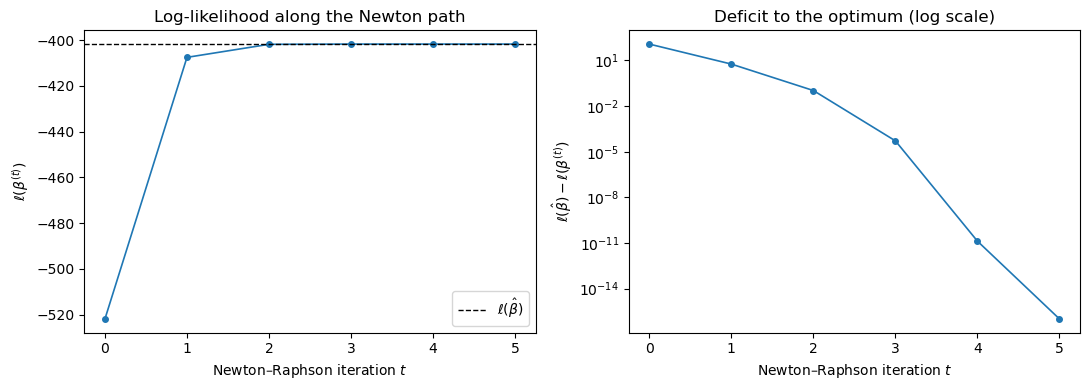

Newton–Raphson: 5 iterations;  BFGS: 21 iterations


In [6]:
ll_star = loglik(βnr_k, X_i_k, y_i)
hist_t = np.asarray(hist_nr)
deficit_t = np.maximum(ll_star - hist_t, 1e-16)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].plot(hist_t, 'o-', ms=4, lw=1.2)
axes[0].axhline(ll_star, color='k', ls='--', lw=1, label=r'$\ell(\hat\beta)$')
axes[0].set_xlabel('Newton–Raphson iteration $t$')
axes[0].set_ylabel(r'$\ell(\beta^{(t)})$')
axes[0].set_title('Log-likelihood along the Newton path')
axes[0].legend()

axes[1].semilogy(deficit_t, 'o-', ms=4, lw=1.2)
axes[1].set_xlabel('Newton–Raphson iteration $t$')
axes[1].set_ylabel(r'$\ell(\hat\beta) - \ell(\beta^{(t)})$')
axes[1].set_title('Deficit to the optimum (log scale)')
plt.tight_layout()
plt.show()

print(f'Newton–Raphson: {iters_nr} iterations;  BFGS: {res_bfgs.nit} iterations')


# 5. Verifying the information identity

We compare the three sample analogs of $\mathcal{I}(\theta_0)$ at the MLE:
$$
\widehat{\mathcal{J}}_I := \frac{1}{I}\sum_i s_i\,s_i^\top, \qquad
\widehat H_I := -\frac{1}{I}\sum_i\nabla_\theta s_i.
$$

Under correct specification, the information identity says these are asymptotically equal. We compute both and inspect the largest discrepancy.

In [7]:
# Per-observation scores at the MLE: s_i = (y_i - Λ_i) x_i
εhat_i = y_i - Λ(X_i_k @ βnr_k)
S_i_k = X_i_k * εhat_i[:, None]                  # (I, K) matrix of scores

Jbar_k_k  = (S_i_k.T @ S_i_k) / I                       # outer product of scores
Hbar_k_k  = -hessian(βnr_k, X_i_k, y_i) / I            # negative average Hessian
diff = Jbar_k_k - Hbar_k_k
print(f'Frobenius norm of (J - (-H))/I            = {np.linalg.norm(diff):.5f}')
print(f'Largest entrywise difference / largest entry = '
      f'{np.max(np.abs(diff)) / np.max(np.abs(Hbar_k_k)):.4f}')


Frobenius norm of (J - (-H))/I            = 726.09087
Largest entrywise difference / largest entry = 0.0494


The two sample analogs of $\mathcal{I}(\theta_0)$ are close but not identical here: the largest
entrywise gap is a few percent of the largest entry of $\widehat H_I$. That is the direction the
information identity predicts under correct specification, since $\mathbb{E}[ss^\top] =
-\mathbb{E}[\nabla s]$ holds in the population and the two sample analogs differ at finite $I$
by ordinary sampling noise.

What this comparison does **not** provide is a decision rule. The gap has a sampling
distribution that we have not derived, so no particular percentage, not the few percent seen
here, and not some larger figure, separates "well specified" from "misspecified". Turning the
discrepancy into a test means using the **information-matrix test** of White (1982), which
compares the distinct elements of $\widehat{\mathcal{J}}_I + \widehat H_I$ against their
estimated covariance and is asymptotically $\chi^2$; alternatively one can calibrate the
statistic by parametric bootstrap under the fitted logit. We do neither here, so the appropriate
reading of the numbers below is descriptive: they are consistent with the logit specification,
and they motivate reporting the sandwich standard error in the next section, which is valid
whether or not the identity holds.

# 6. Three classical tests: LR, Wald, LM

Consider testing the simple linear restriction $H_0: R\beta = r_0$ with $R\in\mathbb{R}^{Q\times K}$ of rank $Q$ (in our application: $\beta_{\text{kids5}} = \beta_{\text{kids618}} = 0$, i.e., children have no effect on LFP). All three tests are asymptotically $\chi^2_Q$ under $H_0$:

$$
\textbf{(LR)}\quad \mathrm{LR} := 2\bigl(\ell_I(\hat\beta) - \ell_I(\tilde\beta)\bigr) \quad\text{(twice the log-lik gap)}
$$

$$
\textbf{(Wald)}\quad W := (R\hat\beta - r_0)^\top\bigl[R\,\widehat V\,R^\top\bigr]^{-1}(R\hat\beta - r_0)
$$

$$
\textbf{(LM)}\quad \mathrm{LM} := \tilde s^\top\,\tilde{\mathcal{I}}^{-1}\,\tilde s \quad\text{(score statistic at the restricted estimate)}
$$

where $\tilde\beta$ is the MLE under the restriction, $\tilde s = \sum_i s_i(\tilde\beta)$, and $\tilde{\mathcal{I}} = -H(\tilde\beta)$.

Under $H_0$, all three converge to the same $\chi^2_Q$ limit. They are *not* numerically equal in finite samples, Berndt and Savin (1977) showed that for linear models with normal errors, $W \geq \mathrm{LR} \geq \mathrm{LM}$, but the orderings are sample-specific in nonlinear models like logit.

In [8]:
# Restricted logit: drop kids5 and kids618 (positions 5 and 6)
keep = [0, 1, 2, 3, 4, 7]
Xr_i_k = X_i_k[:, keep]
nr_r = newton_raphson(Xr_i_k, y_i)
assert nr_r.converged, 'restricted Newton–Raphson did not converge'
βrnr_k = nr_r.β_k

ll_unrestricted = loglik(βnr_k,  X_i_k,  y_i)
ll_restricted   = loglik(βrnr_k, Xr_i_k, y_i)
LR = 2 * (ll_unrestricted - ll_restricted)

# Wald: test β_kids5 = β_kids618 = 0 using the unrestricted variance
R_q_k = np.zeros((2, K))
R_q_k[0, 5] = 1   # kids5
R_q_k[1, 6] = 1   # kids618
r_q = np.zeros(2)
q = R_q_k.shape[0]
βdiff_q = R_q_k @ βnr_k - r_q
W = βdiff_q @ np.linalg.solve(R_q_k @ Vclass_k_k @ R_q_k.T, βdiff_q)

# LM: pad βrnr_k to full length (zeros where kids5, kids618 were)
βrfull_k = np.zeros(K)
βrfull_k[keep] = βrnr_k
sr_k = score(βrfull_k, X_i_k, y_i)
Hr_k_k = -hessian(βrfull_k, X_i_k, y_i)
LM = sr_k @ np.linalg.solve(Hr_k_k, sr_k)

print(f"{'statistic':<10s}{'value':>10s}{'p-value':>14s}")
for name, val in [('LR', LR), ('Wald', W), ('LM', LM)]:
    p = 1 - stats.chi2.cdf(val, df=q)
    print(f'{name:<10s}{val:>10.4f}{p:>14.4e}')
print(f'\nχ²_{q} 95% critical    = {stats.chi2.ppf(0.95, q):.4f}')


statistic      value       p-value
LR           62.0225    3.4084e-14
Wald         53.5403    2.3652e-12
LM           60.4531    7.4607e-14

χ²_2 95% critical    = 5.9915


All three statistics are large and overwhelmingly reject $H_0$: children are highly significant determinants of LFP. The numerical values differ across the three tests by a few percentage points, a typical finite-sample pattern in nonlinear models, but their *p-values* agree to many decimals, since they all sit deep in the right tail of the $\chi^2_2$ distribution. Asymptotically, of course, the three are equivalent, and the choice between them is largely a matter of which is computationally most convenient: LR requires solving the model twice (restricted and unrestricted); Wald only requires the unrestricted estimate; LM only requires the restricted estimate.

# 7. Sandwich standard errors under misspecification

The classical MLE variance estimator $-H^{-1}$ assumes the information identity holds. When the model is misspecified, the conditional density does not actually belong to the parametric family, the information identity fails: the MLE still converges to a well-defined pseudo-true value $\theta^*$ (the KL projection of the true density onto the parametric family), but its asymptotic variance is *not* $\mathcal{I}^{-1}$. Following White (1982),
$$
\sqrt{I}(\hat\theta_I - \theta^*)\xrightarrow{d}\mathcal{N}\bigl(0,\,V_{\text{sand}}\bigr), \qquad V_{\text{sand}} := A^{-1}\,B\,A^{-1},
$$
with $A := -\mathbb{E}[\nabla s_i(\theta^*)]$ and $B := \mathbb{E}[s_i(\theta^*)\,s_i(\theta^*)^\top]$. Under correct specification, $A = B = \mathcal{I}(\theta_0)$ and $V_{\text{sand}}$ collapses back to $\mathcal{I}^{-1}$.

We have already computed both $V_{\text{class}} = -H^{-1}$ and $V_{\text{sand}} = (-H)^{-1}\,J\,(-H)^{-1}$ in §4. Their comparison is a useful diagnostic.

In [9]:
print(f"{'name':<10s}{'classical s.e.':>17s}{'sandwich s.e.':>16s}{'ratio':>10s}")
for name, sc, ss in zip(xnames, seclass_k, sesand_k):
    print(f'{name:<10s}{sc:>17.5f}{ss:>16.5f}{ss/sc:>10.3f}')


name         classical s.e.   sandwich s.e.     ratio
const               0.86037         0.85916     0.999
age                 0.01457         0.01443     0.990
educ                0.04344         0.04442     1.023
exper               0.03206         0.03227     1.007
exper^2             0.00102         0.00101     0.996
kids5               0.20358         0.20303     0.997
kids618             0.07479         0.07983     1.067
nwifeinc            0.00842         0.00907     1.077


The sandwich SEs are within a few percentage points of the classical SEs across all
coefficients, which is what one expects when the logit specification is a reasonable
description of the data: under correct specification the two estimate the same quantity and
differ only by sampling noise. As in §5, the size of the gap is descriptive rather than a test:
we have not derived its null distribution, so no particular ratio marks the boundary of
misspecification. A large and systematic inflation would nonetheless be a signal worth
chasing, pointing at a non-logit link, a missing nonlinearity, or unmodeled heterogeneity.

In applied work the sandwich SE is reported routinely as a robustness check, even with no
specific alternative in mind: a simple robustness check against the costlier failure mode of
overconfidence under misspecification.

# Looking ahead

The MLE / score / sandwich-variance template developed here recurs in the next two lectures and sets the stage for the rest of the course:

* **Lecture 9 (GMM).** The Generalized Method of Moments generalizes MLE by starting from a moment condition $\mathbb{E}[g(z;\theta)] = 0$ rather than a fully specified likelihood. The MLE is the special case in which the moment is the score $g = s$. Asymptotic normality and the sandwich variance carry over almost verbatim, with $\nabla g$ replacing the Hessian and $\mathbb{E}[gg^\top]$ replacing the OPG.

* **Discrete choice.** The logit of this lecture is the simplest member of a much larger family, multinomial logit, conditional logit, nested logit, mixed logit, all estimated by maximum likelihood and all using the same score / Hessian / sandwich machinery developed here. That family is developed in the `dc` series of the broader math+econ+code notebooks (`dc01`–`dc05`), starting from random-utility foundations.

* **Lecture 14 (limited dependent variables).** Tobit and selection models, including the original Mroz (1987) application, combine a binary participation decision with a continuous outcome conditional on participation, and are estimated by MLE on a piecewise log-likelihood. The score and Hessian are more involved but the asymptotic theory is identical to what we have just developed.